## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting? 
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

1 - regression predicts continuous numeric values, while classification predicts catagories/labels
2 - a confusion matrix is a table comparing predicted vs actual classes, it helps us understand the kinds of mistakes the model makes, and what type of mistakes they are, it's more informative than accuracy alone. 
3 - accuracy is correct predictions/ total predictions - it's not enough because of class imbalance, ex 95% is non spam, model always predicts non spam, accuracy is 95% but the model is useless, so they accuracy might not be very informative
4 - RMSE measures average prediction error, tells on average how far off predictions are, bigger errors get penalized more (because squared), lower = better
5 - underfitting is when it is too simple, the model misses patterns, bad training and testing - overfitting is too complex, the model memorizes noise, does great on training but bad on test
6 - splitting is what actually teaches the model - you train so that the model can learn new patterns, and then test on unseen data to make sure the model is learning correctly. choosing k using test performance prevents overfitting, gives realistic performance estimate, and improves generalization, basically forces honesty
7 - predicting labels are simple, easy to interpret, fast decisions, cons are no confidence info and treats 51% and 99% the same - predicting probabilities show confidence, have flexible thresholds, and are better for decision making, cons are that they are slightly more complex and you need to choose cutoff - probabilities usually give more info so are usually better

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


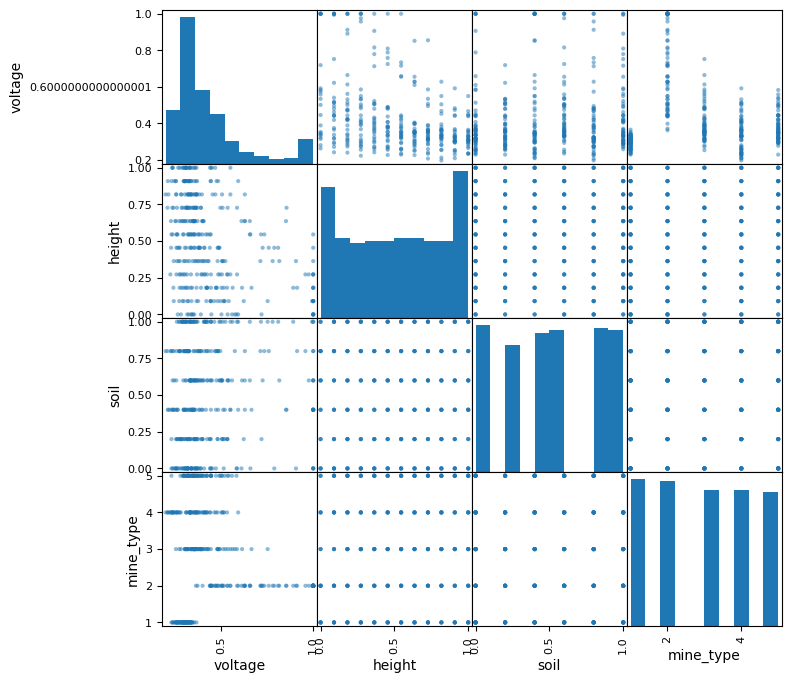


Train size- 169
Test size- 169
Selected k = 6, Cross-validated mean accuracy = 0.4643


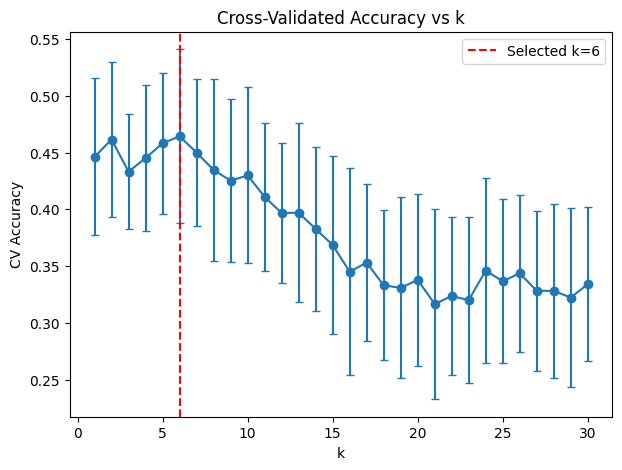

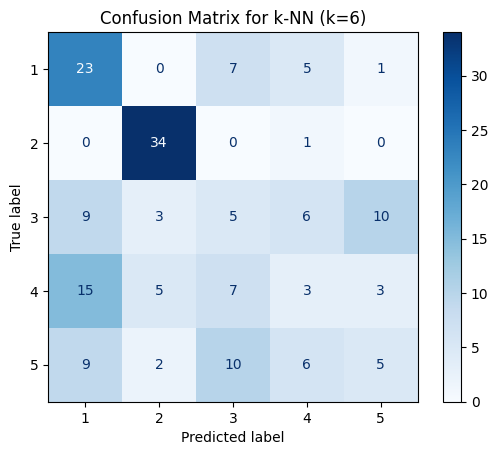

Test accuracy: 0.4142


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
# 1
df = pd.read_csv('data/land_mines.csv')
df.head()
df.describe()
print(df["mine_type"].value_counts())
features = ["voltage", "height", "soil"]
pd.plotting.scatter_matrix(df[features + ["mine_type"]],
                           figsize=(8,8),
                           diagonal="hist")

plt.show()

X = df[features]
y = df["mine_type"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)
print("\nTrain size-", len(X_train))
print("Test size-", len(X_test))

# 3
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

k_values = range(1, 31)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0)

means = []
stds = []

for k in k_values:
    
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    
    means.append(scores.mean())
    stds.append(scores.std())

means = np.array(means)
stds = np.array(stds)
max_idx = np.argmax(means)
max_mean = means[max_idx]
max_std = stds[max_idx]

stable_ks = [k for k, m in zip(k_values, means) if m >= max_mean - max_std]

best_k = min(stable_ks, key=lambda x: abs(x - k_values[max_idx]))

print(f"Selected k = {best_k}, Cross-validated mean accuracy = {max_mean:.4f}")

plt.figure(figsize=(7,5))
plt.errorbar(k_values, means, yerr=stds, marker="o", capsize=3)
plt.axvline(best_k, linestyle="--", color='red', label=f'Selected k={best_k}')
plt.xlabel("k")
plt.ylabel("CV Accuracy")
plt.title("Cross-Validated Accuracy vs k")
plt.legend()
plt.show()

# here, we got k=6. this seems ok, based on the graph it is one of the highest points of accuracy, it's not
# as low as k=1 (overfits, poor generalization), still within 1 std of best CV accuracy - seems like the most
# reasonable choice, based on that info, and also looking at the graph based on accuracy.

# 4
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=[1,2,3,4,5])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4,5])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix for k-NN (k={best_k})")
plt.show()

test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc:.4f}")

# the test accuracy was 41%, which is PRETTY LOWWWW - labels 1 and 2 perfromed the best, being the most
# accuratley predicted. the rest of them, however, didn't do well overall and were generally predicted wrong.
# labels 3 4 and 5 specifically were not predicted well.

# 5

# the model should be used as a decision support tool, not a final decision maker, since misclassifications 
# could be dangerous. it can help prioritize likely mine types and guide inspections, but uncertain 
# predictions should always be verified by experts. in practice, the model should assist human judgment 
# rather than replace it.


**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

train size: 1999
validation size: 500
k = 3, mse = 148065878.44


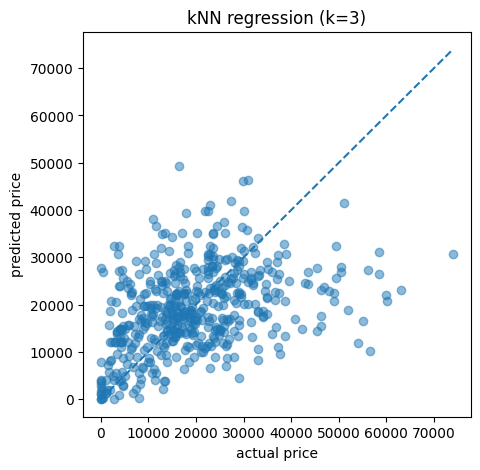

k = 10, mse = 117386675.61


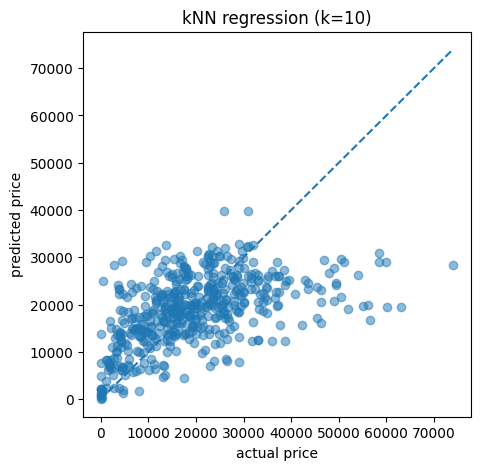

k = 25, mse = 112587758.68


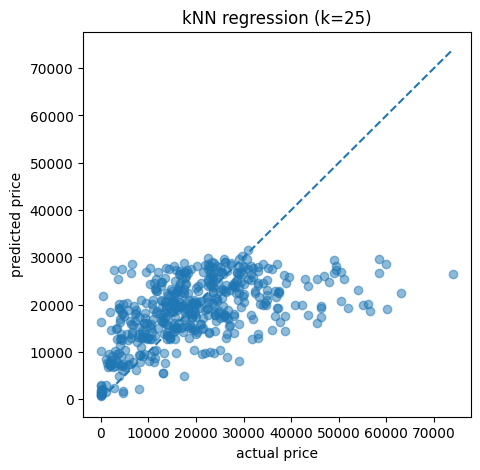

k = 50, mse = 110219323.21


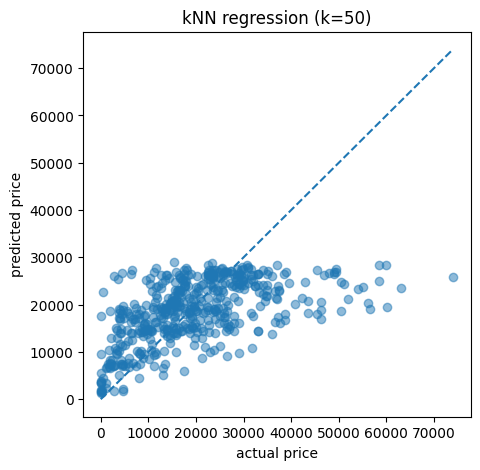

k = 100, mse = 112261649.42


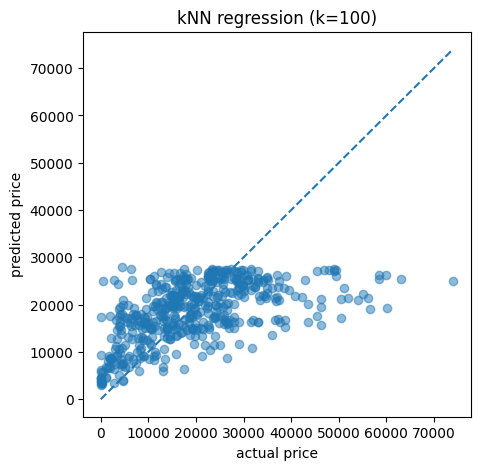

k = 300, mse = 114357657.31


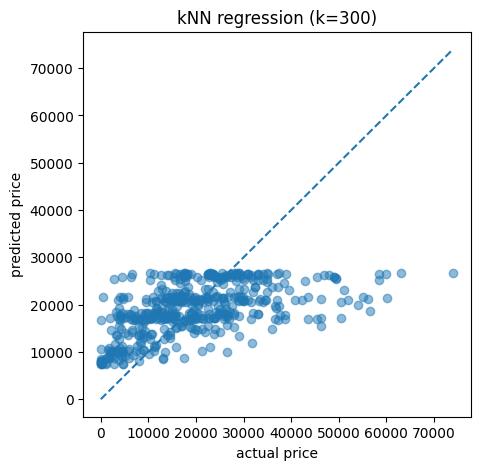

optimal k: 51
lowest mse: 109971241.3091957


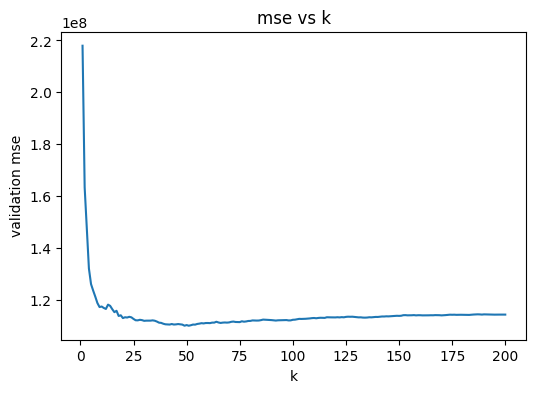

In [37]:
# 1
df = pd.read_csv('data/USA_cars_datasets.csv')
df.isna().sum() # LOTS of NAs to handle
df = df[["price", "year", "mileage"]]
df = df.dropna()
df.head()
df.shape
# 2
cols = ["year", "mileage"]
df[cols] = (df[cols] - df[cols].min()) / (df[cols].max() - df[cols].min())
# 3
from sklearn.model_selection import train_test_split

X = df[["year", "mileage"]]
y = df["price"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("train size:", X_train.shape[0])
print("validation size:", X_val.shape[0])
# 4 
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
k_list = [3, 10, 25, 50, 100, 300]
for k in k_list:

    model = Pipeline([
        ("scaler", MinMaxScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    
    print(f"k = {k}, mse = {mse:.2f}")

    plt.figure(figsize=(5,5))
    plt.scatter(y_val, y_pred, alpha=0.5)
    plt.plot([y_val.min(), y_val.max()],
             [y_val.min(), y_val.max()],
             linestyle="--")
    
    plt.xlabel("actual price")
    plt.ylabel("predicted price")
    plt.title(f"kNN regression (k={k})")
    plt.show()

    # looking at the pattern of these graphs, the predicted scatter plot almost looks like its getting flattened
    # down at the top - this likely means that the model is underfitting and being biased, predicting
    # the same thing more often even if it is not accurate. 

# 5
# the optimal k, based on these graphs seems to be three, but will double check, cause could be better one
# in between

k_list = range(1, 201)
mses = []

for k in k_list:
    model = Pipeline([
        ("scaler", MinMaxScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    mse = mean_squared_error(y_val, y_pred)
    mses.append(mse)

best_k = k_list[np.argmin(mses)]
print("optimal k:", best_k)
print("lowest mse:", min(mses))

plt.figure(figsize=(6,4))
plt.plot(k_list, mses)
plt.xlabel("k")
plt.ylabel("validation mse")
plt.title("mse vs k")
plt.show()
 #said k=51 was best

# 5/6
# it said that k=51 would be the best (lowest mse), but i disagree based on the graphs, as k=50 seems to be
# underfitting hardcore, so I'm going to look at the elbow curve and graphs together instead and say that an optimal
# k would more realistically be around 7, to avoid the underfitting (also makes sense based on where the 
# elbow curve is) - seemingly, after this point, a higher k showed a lot more underfitting, guessing the most common data
# points, which would show more accuracy, but compeletely ignores other values in actuality and isnt accurate
# not overfitting here really, as that would be memorzing stuff, instead its complete ingonring things as k
# increases


**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

                               age   anaemia  creatinine_phosphokinase  \
age                       1.000000  0.088006                 -0.081584   
anaemia                   0.088006  1.000000                 -0.190741   
creatinine_phosphokinase -0.081584 -0.190741                  1.000000   
diabetes                 -0.101012 -0.012729                 -0.009639   
ejection_fraction         0.060098  0.031557                 -0.044080   
high_blood_pressure       0.093289  0.038182                 -0.070590   
platelets                -0.052354 -0.043786                  0.024463   
serum_creatinine          0.159187  0.052174                 -0.016408   
serum_sodium             -0.045966  0.041882                  0.059550   
sex                       0.065430 -0.094769                  0.079791   
smoking                   0.018668 -0.107290                  0.002421   
DEATH_EVENT               0.253729  0.066270                  0.062728   

                          diabetes  e

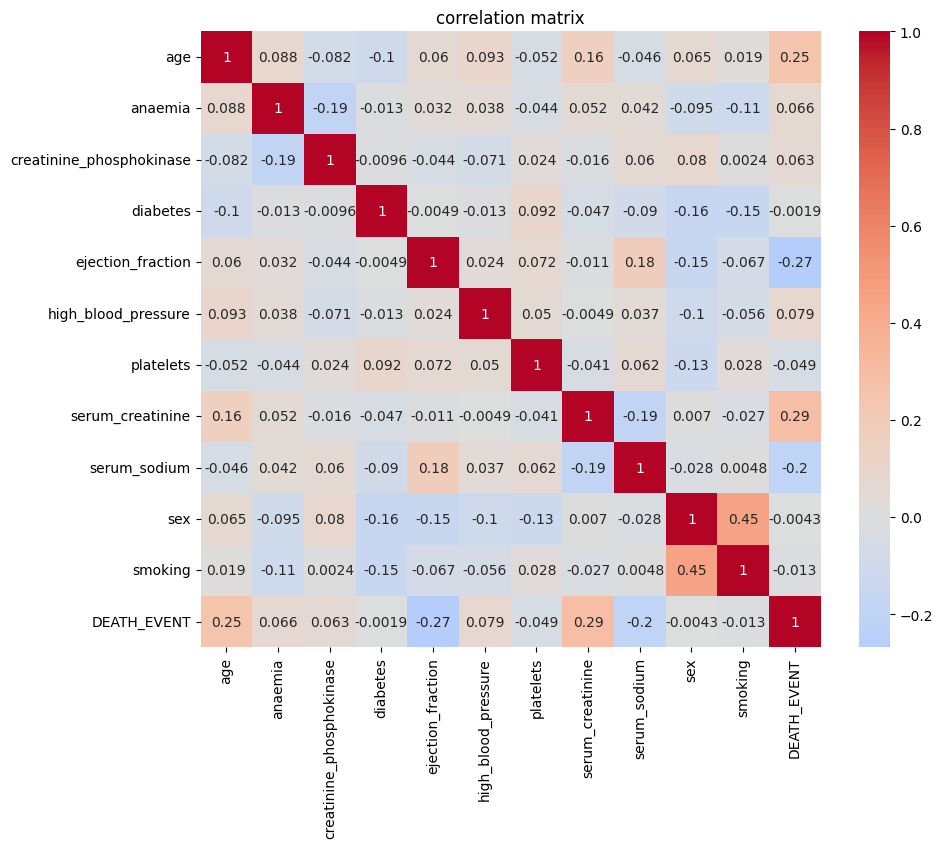


===== anaemia =====
         death_rate  n_people  n_deaths
anaemia                                
0          0.294118       170        50
1          0.356589       129        46

===== diabetes =====
          death_rate  n_people  n_deaths
diabetes                                
0           0.321839       174        56
1           0.320000       125        40

===== high_blood_pressure =====
                     death_rate  n_people  n_deaths
high_blood_pressure                                
0                      0.293814       194        57
1                      0.371429       105        39

===== sex =====
     death_rate  n_people  n_deaths
sex                                
0      0.323810       105        34
1      0.319588       194        62

===== smoking =====
         death_rate  n_people  n_deaths
smoking                                
0          0.325123       203        66
1          0.312500        96        30
X shape: (299, 6)
y shape: (299,)
    age  ejectio

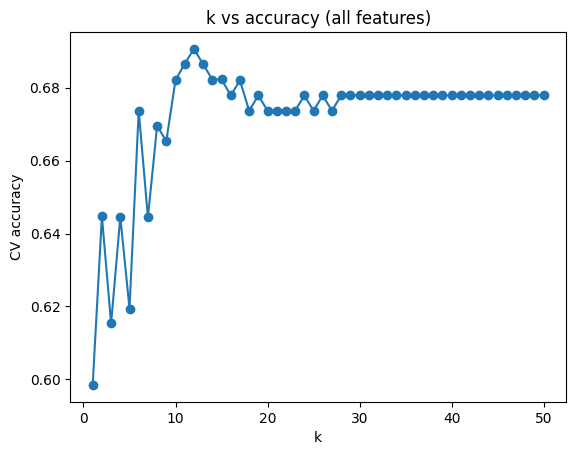

In [60]:
# 1
df = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')
df.isna().sum()
df = df.drop(columns=["time"])
df.head()
df.describe()
# 2
corr = df.corr(numeric_only=True)
print(corr)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("correlation matrix")
plt.show()
# the variables that see to have the highest association with death event are age and serum_c, and ejection
# fraction seems to have the highest inverse relation

# 3
dummies = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]
for var in dummies:
    print(f"\n===== {var} =====")
    
    summary = (
        df.groupby(var)["DEATH_EVENT"]
          .agg(["mean", "count", "sum"])
          .rename(columns={
              "mean": "death_rate",
              "count": "n_people",
              "sum": "n_deaths"
          })
    )
    print(summary)   # amenia dies more at 1, diabetes about even, hbp at 1, sex at 0, smoking at 0

#4
features = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "high_blood_pressure",
    "smoking",
    "anaemia"
]
X = df[features]
y = df["DEATH_EVENT"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())

#5
X_scaled = (X - X.min()) / (X.max() - X.min())
print(X_scaled.head())

#6
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,          # normalized features
    y,                 # target
    test_size=0.2,     # 20% test
    random_state=42,   # keeps split consistent
    stratify=y         # keeps death proportions balanced
)

print("train size:", X_train.shape[0])
print("test size:", X_test.shape[0])

#7
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = range(1, 51)
cv_means = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    cv_means.append(scores.mean())

best_k = k_values[np.argmax(cv_means)]
print("optimal k:", best_k)
print("best CV accuracy:", max(cv_means)) # optimal was k=17, at accuracy 69% (see output below)

model1 = KNeighborsClassifier(n_neighbors=best_k)
model1.fit(X_train, y_train)

preds1 = model1.predict(X_test)
test_acc1 = model1.score(X_test, y_test)
mse1 = mean_squared_error(y_test, preds1)

print("model 1 test accuracy:", test_acc1)
print("model 1 test mse:", mse1)

#8
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

X_all = df.drop(columns=["DEATH_EVENT"])
y_all = df["DEATH_EVENT"]

scaler_all = MinMaxScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all_scaled,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

k_values = range(1, 51)
cv_means_all = []

for k in k_values:
    model_all = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model_all, X_train_all, y_train_all, cv=5)
    cv_means_all.append(scores.mean())

best_k_all = k_values[np.argmax(cv_means_all)]

print("best k (all features):", best_k_all)
print("best CV accuracy:", max(cv_means_all))

final_model_all = KNeighborsClassifier(n_neighbors=best_k_all)
final_model_all.fit(X_train_all, y_train_all)

preds_all = final_model_all.predict(X_test_all)
test_acc_all = final_model_all.score(X_test_all, y_test_all)
mse_all = mean_squared_error(y_test_all, preds_all)

print("model 2 test accuracy:", test_acc_all)
print("model 2 test mse:", mse_all)

plt.plot(k_values, cv_means_all, marker="o")
plt.xlabel("k")
plt.ylabel("CV accuracy")
plt.title("k vs accuracy (all features)")
plt.show()

# both models had the same MSE and accuracy, however, model 1 had best cv accuracy. I'd rather use the
# first model to predict death events, since its cleaner (not using all variables, just most impactful ones) 
# and the model had slightly more CV accuracy. 
# changing the set of predictors only caused small changes in rmse on the test set. using all variables 
# did not substantially improve performance compared to the smaller selected set. this shows that more 
# variables are not always better, since irrelevant or noisy features can add noise to the distance 
# calculations in k-nn and sometimes hurt accuracy. selecting only the most informative variables can 
# perform just as well or better.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on. 

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.


Unique class labels-
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

Animals in each class-

=Class 1 =
['aardvark' 'antelope' 'bear' 'boar' 'buffalo' 'calf' 'cavy' 'cheetah'
 'deer' 'dolphin' 'elephant' 'fruitbat' 'giraffe' 'girl' 'goat' 'gorilla'
 'hamster' 'hare' 'leopard' 'lion' 'lynx' 'mink' 'mole' 'mongoose'
 'opossum' 'oryx' 'platypus' 'polecat' 'pony' 'porpoise' 'puma' 'pussycat'
 'raccoon' 'reindeer' 'seal' 'sealion' 'squirrel' 'vampire' 'vole'
 'wallaby' 'wolf']

=Class 2 =
['chicken' 'crow' 'dove' 'duck' 'flamingo' 'gull' 'hawk' 'kiwi' 'lark'
 'ostrich' 'parakeet' 'penguin' 'pheasant' 'rhea' 'skimmer' 'skua'
 'sparrow' 'swan' 'vulture' 'wren']

=Class 3 =
['pitviper' 'seasnake' 'slowworm' 'tortoise' 'tuatara']

=Class 4 =
['bass' 'carp' 'catfish' 'chub' 'dogfish' 'haddock' 'herring' 'pike'
 'piranha' 'seahorse' 'sole' 'stingray' 'tuna']

=Class 5 =
['frog' 'frog' 'newt' 'toad']

=Class 6 =
['flea' 'gnat' 'honeybee' 'housefly' 'la

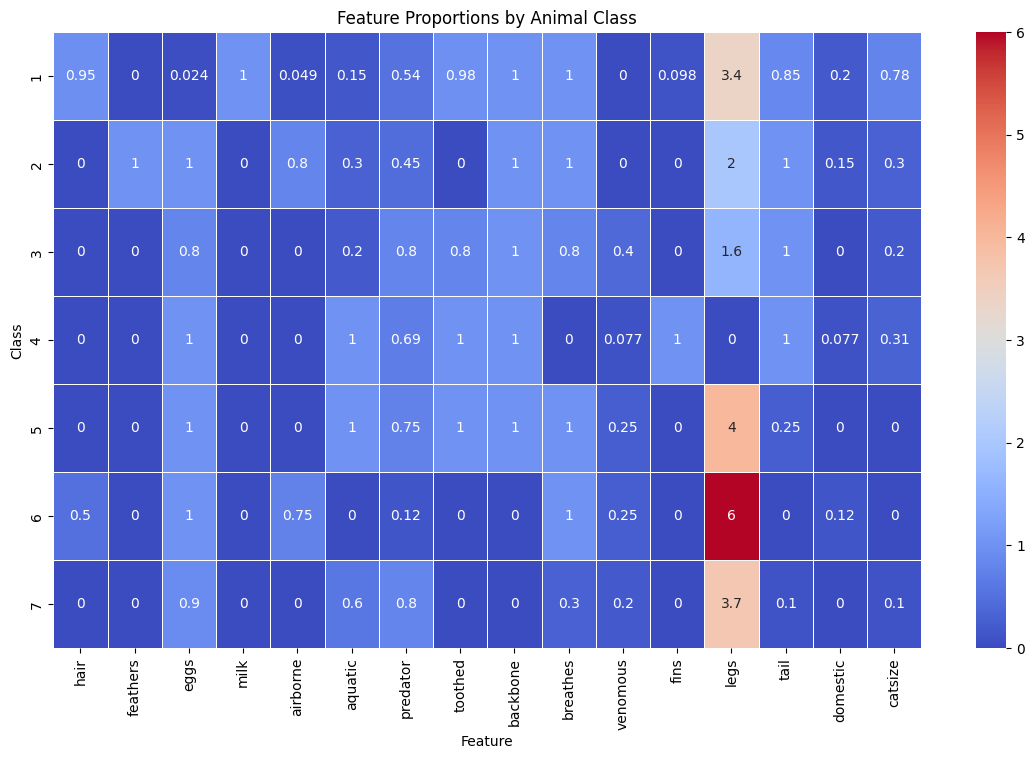

Training set size: 50
Test set size: 51

Class distribution in full dataset:
class
1    41
2    20
3     5
4    13
5     4
6     8
7    10
Name: count, dtype: int64

Class distribution in training set:
class
1    20
2    10
3     3
4     6
5     2
6     4
7     5
Name: count, dtype: int64

Class distribution in test set:
class
1    21
2    10
3     2
4     7
5     2
6     4
7     5
Name: count, dtype: int64
Best k- 1
Best cv accuracy- 0.9
Test accuracy- 0.9803921568627451
Test Accuracy: 0.9803921568627451

Confusion Matrix:
[[21  0  0  0  0  0  0]
 [ 0 10  0  0  0  0  0]
 [ 0  0  1  1  0  0  0]
 [ 0  0  0  7  0  0  0]
 [ 0  0  0  0  2  0  0]
 [ 0  0  0  0  0  4  0]
 [ 0  0  0  0  0  0  5]]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

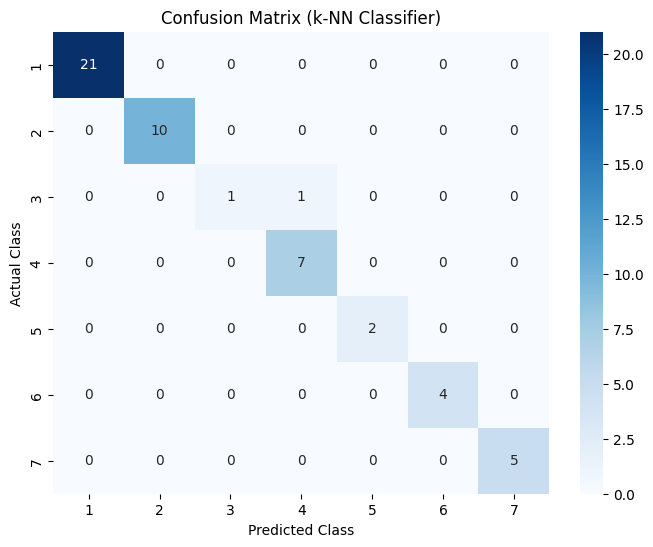

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Best k (3 features): 4
Best CV accuracy: 0.76
Test Accuracy: 0.6666666666666666

Confusion Matrix:
[[19  2  0  0  0  0  0]
 [ 0  7  0  1  0  0  2]
 [ 0  0  0  1  0  0  1]
 [ 0  0  0  7  0  0  0]
 [ 0  0  0  2  0  0  0]
 [ 0  3  0  0  0  0  1]
 [ 0  0  0  4  0  0  1]]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packa

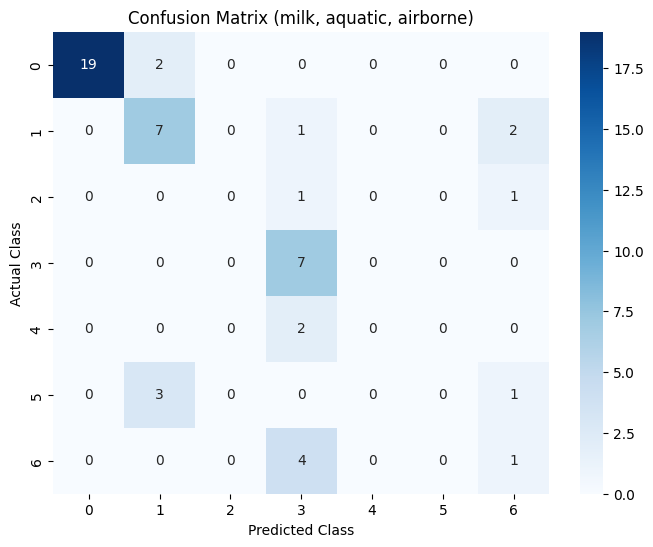


Shape of predicted probability matrix:
(51, 7)

Classes in model:
[1 2 3 4 5 6 7]

First 10 probability rows:
[[0.   0.   0.   0.5  0.25 0.   0.25]
 [1.   0.   0.   0.   0.   0.   0.  ]
 [1.   0.   0.   0.   0.   0.   0.  ]
 [1.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.75 0.   0.   0.   0.25 0.  ]
 [0.   0.   0.   0.5  0.25 0.   0.25]
 [0.   0.75 0.   0.   0.   0.25 0.  ]
 [0.   0.   0.   0.5  0.25 0.   0.25]
 [1.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.75 0.   0.   0.   0.25 0.  ]]


In [ ]:
# 1
df = pd.read_csv('data/zoo.csv')
df.head() #seems to be MOSTLY binary
df.shape # 101, 18
df.columns
print("\nUnique class labels-")
print(sorted(df["class"].unique())) # 1,2,3,5,6,7 classes
print("\nAnimals in each class-")
for c in sorted(df["class"].unique()):
    print(f"\n=Class {c} =")
    animals_in_class = df[df["class"] == c]["animal"].values
    print(animals_in_class)
print("\nNumber of observations in each class:")
for c in sorted(df["class"].unique()):
    count = df[df["class"] == c].shape[0]
    print(f"Class {c}: {count}")
# class 1 seems to be mammals (41), 2 is birds (20), 3 is reptiles (5), 4 is fish (13), 
# 5 is amphibs (4), 6 is bugs (8), 7 is crawfish (10)?
#feature var - see output for variation between features
feature_cols = df.columns.drop(["animal", "class"])
print("\nFeature summary stats-")
print(df[feature_cols].describe())
print("\nFeature means (proportion of 1s for binary vars):")
print(df[feature_cols].mean().sort_values(ascending=False))
print("\nFeature standard deviations:") # see correlation between features
print(df[feature_cols].std().sort_values(ascending=False))
df_features = df.drop(columns=["animal"])
# compute mean feature values by class
class_feature_means = df_features.groupby("class").mean()
print(class_feature_means)
# show correlation between class and the diff features
plt.figure(figsize=(14, 8))
sns.heatmap(
    class_feature_means,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Feature Proportions by Animal Class")
plt.ylabel("Class")
plt.xlabel("Feature")
plt.show()
#seems like legs will be a strong predictor, with high correlation between the classes - that will definitley be good to 
#help predict the class - features that also have more variation in correlation between the classes will help (see graph)

# 2
import pandas as pd
from sklearn.model_selection import train_test_split

# Load data

X = df.drop(columns=["animal", "class"])
y = df["class"]

# split 5050
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)
print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nClass distribution in full dataset:")
print(y.value_counts().sort_index())
print("\nClass distribution in training set:")
print(y_train.value_counts().sort_index())
print("\nClass distribution in test set:")
print(y_test.value_counts().sort_index())

# 3

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
k_values = range(1, 31)
cv_means = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    cv_means.append(scores.mean())

best_k = k_values[np.argmax(cv_means)]
print("Best k-", best_k)
print("Best cv accuracy-", max(cv_means))

final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)

print("Test accuracy-", test_accuracy)

#Tested values of k from 1 to 30 For each k, computed average cross validated accuracy- 
# Chose the k that maximized validation accuracy
# Then fit the final model using that optimal k
# Finally evaluated performance on the test set
# because its such a small dataset and k=1 is really low, a little worried about overfitting, but this
# was the k selected by cross validation

# 4
y_pred = final_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix (k-NN Classifier)")
plt.show()

# the C matrix shows that the model was SUPER accurate, getting almost every prediction correct, besides one.
# the one that it got wrong, it predicted a reptile (3) as a fish (4) - this could make sense, bc some
# reptiles and many fish dont have legs, may be of a similar texture, and move similarly, etc, so catagorically
# could be hard to differentiate due to the species vast uniqueness

# 5
X_small = df[["milk", "aquatic", "airborne"]]
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X_small,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = range(1, 21)
cv_means = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    cv_means.append(scores.mean())

best_k = k_values[np.argmax(cv_means)]

print("Best k (3 features):", best_k)
print("Best CV accuracy:", max(cv_means))

model_small = KNeighborsClassifier(n_neighbors=best_k)
model_small.fit(X_train_scaled, y_train)
y_pred_small = model_small.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred_small))

cm_small = confusion_matrix(y_test, y_pred_small)

print("\nConfusion Matrix:")
print(cm_small)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_small,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix (milk, aquatic, airborne)")
plt.show()

probs = model_small.predict_proba(X_test_scaled)

print("\nShape of predicted probability matrix:")
print(probs.shape)
print("\nClasses in model:")
print(model_small.classes_)
print("\nFirst 10 probability rows:")
print(probs[:10])

# yes, i was able to produce all classes. however, with less features, the model was significantly less
# accurate (66% on test) than the model using all features. this seems to show that, in this case, more
# features used does result in a higher accuracy when the model is applied - also, the model reclassed the 
# features, labeled starting at 0, but all 7 classes are still there.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

Best k- 29
Minimum SSE- 854551.1759809752
Final SSE on test set: 854551.1759809752
    Review Scores Rating  Price  Beds  Predicted Review Scores Rating
0                    NaN  145.0   1.0                       95.965517
1                    NaN   37.0   1.0                       91.379310
2                    NaN   28.0   1.0                       87.275862
3                    NaN  199.0   3.0                       88.758621
13                   NaN   68.0   1.0                       92.448276

Number of predicted ratings: 8282


/var/folders/xj/pd7w9qz52gq4znklqy7h1rqh0000gn/T/ipykernel_20708/2347161910.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_reviews_clean["Predicted Review Scores Rating"] = predicted_ratings


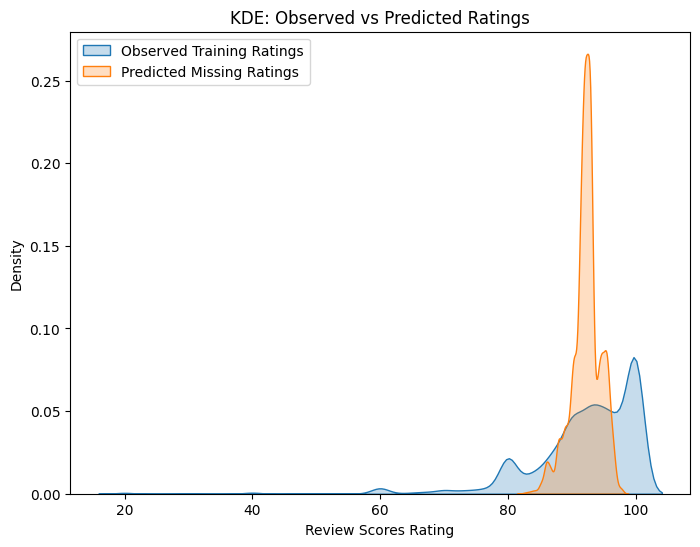

In [ ]:
# 1 
df = pd.read_csv('data/airbnb_hw.csv')
df = df.loc[:, ["Review Scores Rating", "Price", "Beds"]]
df.head() # doubled checked, looks good
df.shape # 30478, 3
df["Price"] = (
    df["Price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)

# 2
missing_reviews = df.loc[df["Review Scores Rating"].isnull()]
df_clean = df.loc[~df["Review Scores Rating"].isnull()]

# 3
df_complete = df.dropna(axis=0, how='any')

# 4

X = df_complete.loc[:, ["Price", "Beds"]]
y = df_complete["Review Scores Rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=42
)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
k_values = range(1, 31)
sse_values = []
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    sse = np.sum((y_test - y_pred) ** 2)
    sse_values.append(sse)

best_k = k_values[np.argmin(sse_values)]
print("Best k-", best_k)
print("Minimum SSE-", min(sse_values))

final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
y_pred_final = final_model.predict(X_test_scaled)
final_sse = np.sum((y_test - y_pred_final) ** 2)

print("Final SSE on test set:", final_sse)

# to choose k, i split the data into two 50/50 sets, to train and test on, for values k 1-30, a kNN regression
# model was fit using the training data, predictions were made on the test set, and sum squared error was found
# the value of k that minimized sse was selected as the optimal # of neighbors

# 5
missing_reviews_clean = missing_reviews.dropna(subset=["Price", "Beds"])
X_missing = missing_reviews_clean.loc[:, ["Price", "Beds"]]
X_missing_scaled = scaler.transform(X_missing)
predicted_ratings = final_model.predict(X_missing_scaled)
missing_reviews_clean["Predicted Review Scores Rating"] = predicted_ratings

print(missing_reviews_clean.head())
print("\nNumber of predicted ratings:", len(predicted_ratings))

#6

train_ratings = y_train
predicted_ratings = missing_reviews_clean["Predicted Review Scores Rating"]

plt.figure(figsize=(8,6))
sns.kdeplot(train_ratings, label="Observed Training Ratings", fill=True)
sns.kdeplot(predicted_ratings, label="Predicted Missing Ratings", fill=True)
plt.xlabel("Review Scores Rating")
plt.ylabel("Density")
plt.title("KDE: Observed vs Predicted Ratings")
plt.legend()
plt.show()

# the distribution of ratings doesnt seem to be similar between predicted v actual, 
# with the prediction having predicted the same value repeatedly MUCH more than the actual ratings.
# the actual seems to have a more even distribution, while the model does not, which indicates that
# there could be some underfitting going on, predicting the same thing too often


**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)

7 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 222 254 254 254 254 241 198 198 198 198 198 198 19

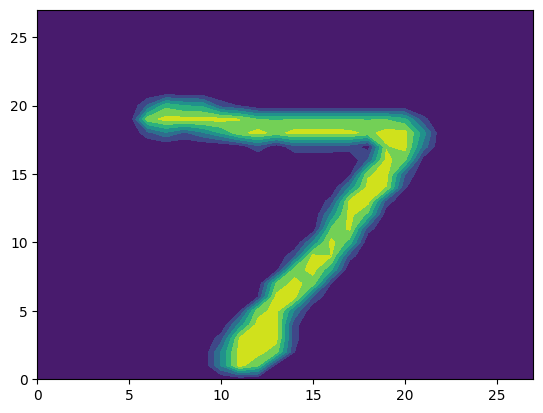

2 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 116 125 171 255 255 150  93   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 169 253 253 253 253 253 253 218  30   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 169 253 253 253 213 142 176 253 253 122   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  52 250 253 210  32  12   0   6 206 253 140   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  77 251 210  25   0   0   0 122 248 253  65   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  31  18   0   0   0   0 209 253 253  65   

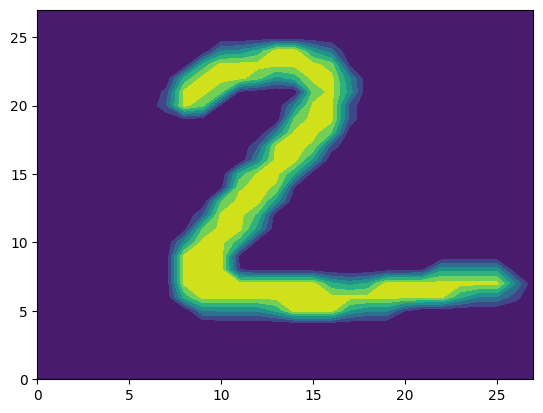

1 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  38 254 109   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  87 252  82   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 135 241   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  45 244 150   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  84 254  63   

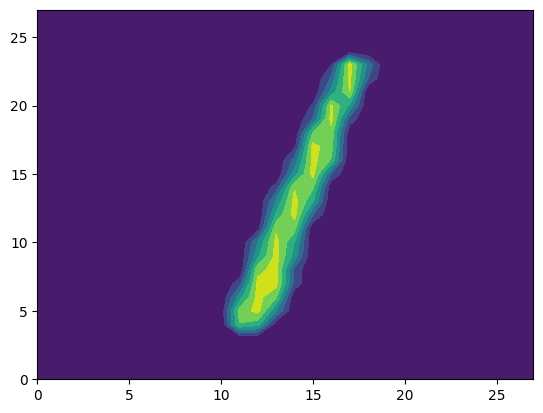

0 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  11 150 253 202  31   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  37 251 251 253 107   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  21 197 251 251 253 107   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 110 190 251 251 251 253 169 109  62   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 253 251 251 251 251 253 251 251 22

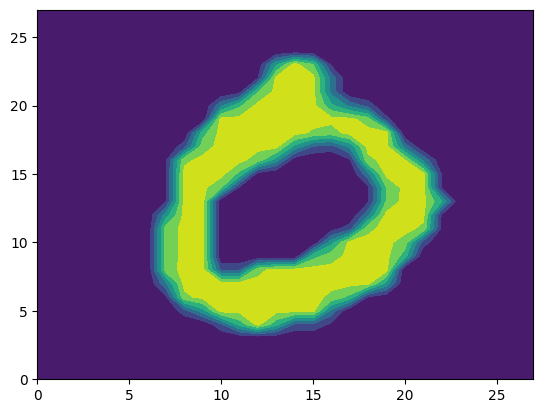

4 

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  50 224   0   0   0   0   0   0   0  70  29   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 121 231   0   0   0   0   0   0   0 148 168   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   4 195 231   0   0   0   0   0   0   0  96 210  11   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  69 252 134   0   0   0   0   0   0   

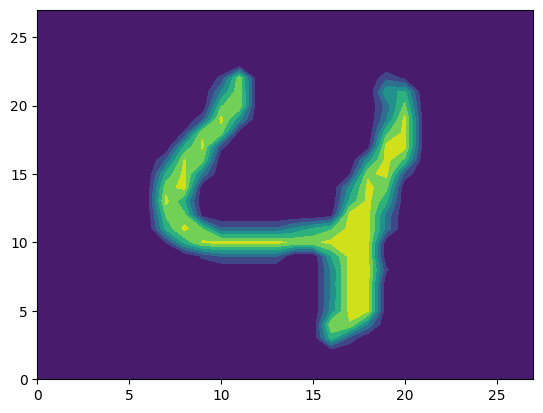

(60000, 28, 28)
(10000, 28, 28)
(28, 28)
(28, 28)
(60000,)
(10000,)
X_train shape: (60000, 784)
X_test shape: (10000, 784)
k = 1, Accuracy = 0.9691
k = 2, Accuracy = 0.9627
k = 3, Accuracy = 0.9705
k = 4, Accuracy = 0.9682
k = 5, Accuracy = 0.9688
k = 6, Accuracy = 0.9677
k = 7, Accuracy = 0.9694
k = 8, Accuracy = 0.9670
k = 9, Accuracy = 0.9659
k = 10, Accuracy = 0.9665
k = 11, Accuracy = 0.9668
k = 12, Accuracy = 0.9661
k = 13, Accuracy = 0.9653
k = 14, Accuracy = 0.9640
k = 15, Accuracy = 0.9633
k = 16, Accuracy = 0.9632
k = 17, Accuracy = 0.9630
k = 18, Accuracy = 0.9633
k = 19, Accuracy = 0.9632
k = 20, Accuracy = 0.9625

Best k: 3
Best accuracy: 0.9705
Test set accuracy: 0.9705
Confusion matrix:
 [[ 974    1    1    0    0    1    2    1    0    0]
 [   0 1133    2    0    0    0    0    0    0    0]
 [  10    9  996    2    0    0    0   13    2    0]
 [   0    2    4  976    1   13    1    7    3    3]
 [   1    6    0    0  950    0    4    2    0   19]
 [   6    1    0   11  

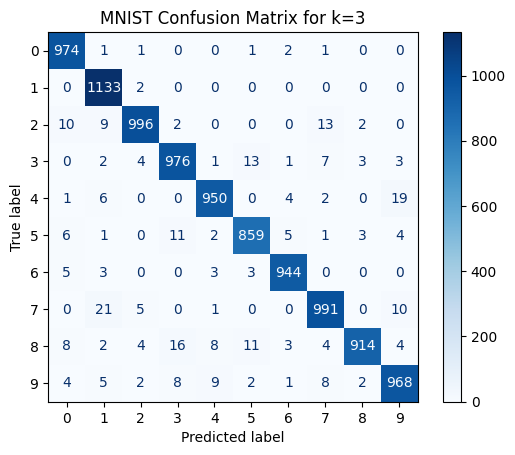

In [ ]:
# 1 
from tensorflow.keras.datasets import mnist
df = mnist.load_data('minst.db')

train,test = df
X_train, y_train = train
X_test, y_test = test

import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5): 
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()

# 2
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)# (60000, 28, 28)
print(X_test.shape)#(10000, 28, 28)
print(X_train[i].shape) # (28,28)
print(X_test[i].shape)# (28,28)
print(y_train.shape)# (60000,)
print(y_test.shape) #(10000,)

#3
X_train_flat = np.zeros((X_train.shape[0], 784))
X_test_flat = np.zeros((X_test.shape[0], 784))

for i in range(X_train.shape[0]):
    X_train_flat[i, :] = X_train[i].reshape(784)

for i in range(X_test.shape[0]):
    X_test_flat[i, :] = X_test[i].reshape(784)

print("X_train shape:", X_train_flat.shape)
print("X_test shape:", X_test_flat.shape)
# X_train shape: (60000, 784)
# X_test shape: (10000, 784)

#4
k_values = range(1, 21)

accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_flat, y_train)
    
    y_pred = knn.predict(X_test_flat)
    accuracy = accuracy_score(y_test, y_pred)
    
    accuracies.append(accuracy)
    print(f"k = {k}, Accuracy = {accuracy:.4f}")

best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("\nBest k:", best_k)
print("Best accuracy:", best_accuracy)

# see output, looked at a bunch of diff ks and their accuracy, then found the best one (k=3)

# 5
knn = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
knn.fit(X_train_flat, y_train)

y_pred = knn.predict(X_test_flat)

accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy:", accuracy)
cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title("MNIST Confusion Matrix for k=3")
plt.show()

# the accuracy for k=3 was Best accuracy: 0.9705 -Test set accuracy: 0.9705 - this is VERY accurate, and 
# didnt lose accuracy when tested, the confusion matrix showcases this high accuracy, showing very few mispredictions
# interesting to see that for the optimal k, accuracy is close to perfect

# 6

# digit 2 is often misclassified as 0,1,7, 3 is misclassified as 5,7 most often, 4 as 1,9, 
# 5 as 3,6, 7 as 1, 8 as 3,5,6, 9 as 4,7
# this makes sense, as the numbers getting mixed up are kind of visually similar, 
# loops, straight lines, and slants would be the main source of error

# 7
#computers see images by turning them into numbers each pixel is a value for grayscale or three 
# numbers for rgb color channels each from 0 to 255 to make tabular data you flatten the height x width x 3 matrix 
# into a 1d vector each row is an image each column a pixel value for a color channel example a 100x100 rgb image 
# has 100x100x3 = 30000 features per row this lets ml treat images like normal numeric data
